# Leveraged Treasuries + Tail Hedge (Spitznagel Structure)

This notebook applies Spitznagel's tail-hedging thesis to **US Treasury futures**:
- **ZN** (10-Year T-Note) — the workhorse of fixed income
- **ZB** (30-Year T-Bond) — longer duration, more convexity

## Thesis

Treasuries have a unique property: they tend to **rally during equity crises**
(flight-to-quality). This means:
1. Levered treasuries can produce equity-like returns with different risk profiles
2. Put protection on bonds hedges against the **opposite** tail: rate hikes (2022)
3. A treasury+puts portfolio is naturally **anti-correlated** with equities

We test:
- Unhedged ZN and ZB at multiple leverage levels
- ZN/ZB + monthly OTM puts (protecting against rate spike selloffs)
- Comparison with equity (ES) and FX carry results

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = '../data/databento'
MONTH_CODES = {'F':1,'G':2,'H':3,'J':4,'K':5,'M':6,
               'N':7,'Q':8,'U':9,'V':10,'X':11,'Z':12}

## 1. Load Treasury Front-Month Futures

In [2]:
def load_front_month(filename, prefix='ZN'):
    fut = pd.read_parquet(f'{DATA_DIR}/{filename}')
    # Filter to outright contracts only (no spreads or user-defined)
    outrights = fut[
        (~fut['symbol'].str.contains('-', na=False)) &
        (~fut['symbol'].str.startswith('UD:', na=False)) &
        (fut['symbol'].str.startswith(prefix, na=False))
    ].copy()
    outrights = outrights.sort_index()

    grouped = outrights.groupby(outrights.index)
    dates = sorted(grouped.groups.keys())

    front_records = []
    for ts in dates:
        day = grouped.get_group(ts)
        # Safe single-row selection via iloc[argmax()]
        max_vol_pos = day['volume'].values.argmax()
        front = day.iloc[max_vol_pos]
        date_norm = ts.normalize().tz_localize(None) if ts.tz is not None else ts.normalize()

        front_records.append({
            'date': date_norm,
            'symbol': front['symbol'],
            'close': float(front['close']),
            'volume': int(front['volume']),
        })

    df = pd.DataFrame(front_records).set_index('date')
    df = df[~df.index.duplicated(keep='first')]
    df['return'] = df['close'].pct_change()
    return df

zn_fut = load_front_month('ZN_FUT_ohlcv1d.parquet', prefix='ZN')
zb_fut = load_front_month('ZB_FUT_ohlcv1d.parquet', prefix='ZB')

for name, fut in [('ZN (10yr)', zn_fut), ('ZB (30yr)', zb_fut)]:
    print(f'{name}:')
    print(f'  Days: {len(fut):,}')
    print(f'  Range: {fut.index.min().date()} to {fut.index.max().date()}')
    print(f'  Price: {fut["close"].min():.3f} to {fut["close"].max():.3f}')
    print(f'  Avg volume: {fut["volume"].mean():,.0f}')
    print()

ZN (10yr):
  Days: 4,884
  Range: 2010-06-06 to 2026-02-27
  Price: 105.484 to 140.344
  Avg volume: 1,064,323

ZB (30yr):
  Days: 4,884
  Range: 2010-06-06 to 2026-02-27
  Price: 107.844 to 185.094
  Avg volume: 253,387



## 2. Treasury Return Profile

Treasury futures embed the term premium. The front-month return captures
the total return from holding the bond, including carry (coupon - financing cost).

In [3]:
for name, fut in [('ZN (10yr)', zn_fut), ('ZB (30yr)', zb_fut)]:
    daily = fut[['close', 'return']].dropna()
    annual = daily['close'].resample('YE').last().pct_change().dropna()

    print(f'{name} Annual Returns')
    print('=' * 40)
    for date, ret in annual.items():
        print(f'  {date.year}: {ret:>7.1%}')
    avg = annual.mean()
    med = annual.median()
    print(f'  {"Avg":>4}: {avg:>7.1%}')
    print(f'  {"Med":>4}: {med:>7.1%}')

    total = daily['close'].iloc[-1] / daily['close'].iloc[0]
    years = (daily.index[-1] - daily.index[0]).days / 365.25
    cagr = total ** (1/years) - 1
    vol = daily['return'].std() * np.sqrt(252)
    sharpe = cagr / vol if vol > 0 else 0
    print(f'  Cumulative: {total:.3f}x in {years:.1f} years')
    print(f'  CAGR: {cagr:.1%}, Vol: {vol:.1%}, Sharpe: {sharpe:.3f}')
    print()

ZN (10yr) Annual Returns
  2011:    8.9%
  2012:    1.1%
  2013:   -7.3%
  2014:    3.1%
  2015:   -0.6%
  2016:   -1.4%
  2017:   -0.1%
  2018:   -1.7%
  2019:    5.2%
  2020:    7.6%
  2021:   -5.6%
  2022:  -13.9%
  2023:    0.4%
  2024:   -3.5%
  2025:    3.2%
  2026:    1.4%
   Avg:   -0.2%
   Med:    0.2%
  Cumulative: 0.941x in 15.7 years
  CAGR: -0.4%, Vol: 5.0%, Sharpe: -0.077

ZB (30yr) Annual Returns
  2011:   18.3%
  2012:    1.8%
  2013:  -12.9%
  2014:   12.8%
  2015:    6.2%
  2016:   -2.1%
  2017:    1.7%
  2018:   -4.5%
  2019:    6.6%
  2020:   11.2%
  2021:   -7.5%
  2022:  -22.0%
  2023:   -0.2%
  2024:   -8.6%
  2025:    1.3%
  2026:    3.0%
   Avg:    0.3%
   Med:    1.5%
  Cumulative: 0.952x in 15.7 years
  CAGR: -0.3%, Vol: 9.7%, Sharpe: -0.032



## 3. Load Treasury Options

OZN = options on 10-Year T-Note futures (ZN)
OZB = options on 30-Year T-Bond futures (ZB)

In [4]:
import os

def load_treasury_options(filename, label):
    path = f'{DATA_DIR}/{filename}'
    if not os.path.exists(path):
        print(f'{label} NOT FOUND: {path}')
        return pd.DataFrame()
    df = pd.read_parquet(path)
    # Handle ts_event in index vs column
    if 'ts_event' not in df.columns and df.index.name == 'ts_event':
        df = df.reset_index()
    elif 'ts_event' not in df.columns:
        df['ts_event'] = df.index
    df = df[df['symbol'].notna()].copy()
    print(f'{label}: {len(df):,} rows, {df["symbol"].nunique()} symbols')
    print(f'  Date range: {df["ts_event"].min()} to {df["ts_event"].max()}')
    return df

ozn_opts_raw = load_treasury_options('OZN_OPT_ohlcv1d.parquet', 'OZN (10yr opts)')
ozb_opts_raw = load_treasury_options('OZB_OPT_ohlcv1d.parquet', 'OZB (30yr opts)')

OZN (10yr opts): 1,483,996 rows, 789567 symbols
  Date range: 2010-07-01 00:00:00+00:00 to 2026-02-27 00:00:00+00:00
OZB (30yr opts): 1,313,484 rows, 540244 symbols
  Date range: 2010-06-06 00:00:00+00:00 to 2026-02-27 00:00:00+00:00


In [5]:
def parse_treasury_option(symbol, trade_date=None):
    # Parse treasury option symbols like 'OZNF1 P1290' or 'OZBZ3 C0138'.
    # Format: {ROOT}{MONTH}{YEAR} {P|C}{STRIKE}
    # OZN strikes: divide by 10 (1290 -> 129.0)
    # OZB strikes: use as-is (0138 -> 138)
    if symbol is None:
        return None
    parts = symbol.split()
    if len(parts) != 2:
        return None

    contract_part = parts[0]  # e.g., OZNF1, OZBZ3
    strike_str = parts[1]     # e.g., P1290, C0138

    # Determine root (OZN or OZB)
    if contract_part.startswith('OZN'):
        root = 'OZN'
        rest = contract_part[3:]  # e.g., F1, N3
        strike_divisor = 10.0
    elif contract_part.startswith('OZB'):
        root = 'OZB'
        rest = contract_part[3:]
        strike_divisor = 1.0
    else:
        return None

    if len(rest) < 2:
        return None
    month_char = rest[0]
    year_str = rest[1:]

    if month_char not in MONTH_CODES:
        return None
    try:
        yr = int(year_str)
    except ValueError:
        return None

    # Year disambiguation using trade_date context
    if trade_date is not None:
        td = pd.Timestamp(trade_date)
        if td.tz is not None:
            td = td.tz_localize(None)
        trade_year = td.year
        candidate_2010s = 2010 + yr
        candidate_2020s = 2020 + yr
        if abs(candidate_2020s - trade_year) <= 2:
            year = candidate_2020s
        elif abs(candidate_2010s - trade_year) <= 2:
            year = candidate_2010s
        else:
            year = candidate_2010s if abs(candidate_2010s - trade_year) < abs(candidate_2020s - trade_year) else candidate_2020s
    else:
        year = 2010 + yr if yr <= 6 else 2020 + yr

    month = MONTH_CODES[month_char]

    if strike_str.startswith('P'):
        opt_type = 'P'
        strike_raw = strike_str[1:]
    elif strike_str.startswith('C'):
        opt_type = 'C'
        strike_raw = strike_str[1:]
    else:
        return None

    try:
        strike = float(strike_raw) / strike_divisor
    except ValueError:
        return None

    # Expiry: ~25th of the month before the contract month
    exp_month = month - 1 if month > 1 else 12
    exp_year = year if month > 1 else year - 1
    try:
        expiry = pd.Timestamp(exp_year, exp_month, 25)
    except:
        expiry = pd.Timestamp(exp_year, exp_month, 20)

    return {
        'root': root,
        'opt_type': opt_type,
        'strike': strike,
        'month': month,
        'year': year,
        'expiry': expiry,
    }

# Parse both sets of options
for label, opts_raw, fut_name in [('OZN', ozn_opts_raw, 'ZN'),
                                    ('OZB', ozb_opts_raw, 'ZB')]:
    if len(opts_raw) == 0:
        print(f'{label}: No data')
        continue

    parsed = []
    for _, row in opts_raw.iterrows():
        trade_date = row['ts_event']
        p = parse_treasury_option(row['symbol'], trade_date=trade_date)
        if p is not None:
            parsed.append({
                'date': pd.Timestamp(trade_date).tz_localize(None) if pd.Timestamp(trade_date).tz is not None else pd.Timestamp(trade_date),
                'symbol': row['symbol'],
                'close': row['close'],
                'volume': row['volume'],
                'opt_type': p['opt_type'],
                'strike': p['strike'],
                'month': p['month'],
                'year': p['year'],
                'expiry': p['expiry'],
                'root': p['root'],
            })

    if len(parsed) == 0:
        print(f'{label}: No options parsed')
        if label == 'OZN':
            ozn_opts = pd.DataFrame()
        else:
            ozb_opts = pd.DataFrame()
        continue

    df = pd.DataFrame(parsed)
    puts = df[df['opt_type'] == 'P']
    calls = df[df['opt_type'] == 'C']
    print()
    print(f'{label}: Parsed {len(df):,} options ({len(puts):,} puts, {len(calls):,} calls)')
    print(f'  Strike range: {df["strike"].min():.1f} to {df["strike"].max():.1f}')
    print(f'  Date range: {df["date"].min().date()} to {df["date"].max().date()}')

    if label == 'OZN':
        ozn_opts = df
    else:
        ozb_opts = df

# Ensure variables exist
if 'ozn_opts' not in dir():
    ozn_opts = pd.DataFrame()
if 'ozb_opts' not in dir():
    ozb_opts = pd.DataFrame()


OZN: Parsed 436,661 options (218,884 puts, 217,777 calls)
  Strike range: 75.0 to 260.0
  Date range: 2010-07-01 to 2026-02-27



OZB: Parsed 472,432 options (235,362 puts, 237,070 calls)
  Strike range: 81.0 to 4000.0
  Date range: 2010-06-06 to 2026-02-27


## 4. Monthly Put Selection

In [6]:
def select_monthly_treasury_puts(opts_df, front_prices, otm_target=0.96, min_vol=3):
    # Select one OTM put per month for treasury options.
    # otm_target=0.96 means 4% below spot (less OTM than equities because
    # treasury moves are smaller in percentage terms).
    puts = opts_df[opts_df['opt_type'] == 'P'].copy()
    if len(puts) == 0:
        return pd.DataFrame()

    puts['ym'] = puts['date'].dt.to_period('M')
    selections = []

    for ym, group in puts.groupby('ym'):
        entry_date = group['date'].min()
        near_idx = front_prices.index.get_indexer([entry_date], method='nearest')
        if near_idx[0] < 0:
            continue
        underlying = float(front_prices.iloc[near_idx[0]]['close'])
        if underlying <= 0:
            continue

        first_day = group[group['date'] == entry_date].copy()
        if len(first_day) == 0:
            continue

        first_day['moneyness'] = first_day['strike'] / underlying
        otm = first_day[
            (first_day['moneyness'] < 1.0) &
            (first_day['moneyness'] > 0.85) &
            (first_day['close'] > 0) &
            (first_day['volume'] >= min_vol)
        ]
        if len(otm) == 0:
            continue

        otm = otm.copy()
        otm['dist'] = abs(otm['moneyness'] - otm_target)
        best = otm.nsmallest(3, 'dist')
        selected = best.loc[best['volume'].idxmax()]

        selections.append({
            'entry_date': entry_date,
            'symbol': selected['symbol'],
            'strike': selected['strike'],
            'entry_price': selected['close'],
            'expiry': selected['expiry'],
            'underlying': underlying,
            'moneyness': selected['moneyness'],
            'volume': selected['volume'],
        })

    return pd.DataFrame(selections)

# Select puts for ZN and ZB
for label, opts, fut in [('ZN', ozn_opts, zn_fut), ('ZB', ozb_opts, zb_fut)]:
    if len(opts) == 0:
        print(f'{label}: No options data')
        continue
    sels = select_monthly_treasury_puts(opts, fut, otm_target=0.96)
    print(f'{label} put selections: {len(sels)} months')
    if len(sels) > 0:
        print(f'  Avg moneyness: {sels["moneyness"].mean():.3f}')
        print(f'  Avg entry price: {sels["entry_price"].mean():.4f}')
        print(f'  Avg volume: {sels["volume"].mean():.0f}')
        print('  First 5:')
        for _, r in sels.head(5).iterrows():
            print(f'    {r["entry_date"].strftime("%Y-%m") if hasattr(r["entry_date"], "strftime") else r["entry_date"]}  {r["symbol"]:25s}  K={r["strike"]:.1f}  S={r["underlying"]:.3f}  m={r["moneyness"]:.3f}  px={r["entry_price"]:.4f}')
    print()

    if label == 'ZN':
        zn_put_sels = sels
    else:
        zb_put_sels = sels

if 'zn_put_sels' not in dir():
    zn_put_sels = pd.DataFrame()
if 'zb_put_sels' not in dir():
    zb_put_sels = pd.DataFrame()

ZN put selections: 176 months
  Avg moneyness: 0.967
  Avg entry price: 0.1475
  Avg volume: 840
  First 5:
    2010-07  OZNQ0 P1175                K=117.5  S=122.516  m=0.959  px=0.0156
    2010-09  OZNX0 P1200                K=120.0  S=124.859  m=0.961  px=0.2188
    2010-10  OZNZ0 P1220                K=122.0  S=126.156  m=0.967  px=0.2344
    2010-11  OZNZ0 P1220                K=122.0  S=126.312  m=0.966  px=0.0781
    2010-12  OZNH1 P1180                K=118.0  S=122.906  m=0.960  px=0.4844



ZB put selections: 66 months
  Avg moneyness: 0.962
  Avg entry price: 0.4136
  Avg volume: 864
  First 5:
    2010-06  OZBN0 P0118                K=118.0  S=124.531  m=0.948  px=0.0938
    2010-07  OZBQ0 P0123                K=123.0  S=127.656  m=0.964  px=0.2500
    2010-08  OZBU0 P0128                K=128.0  S=128.375  m=0.997  px=1.3125
    2010-09  OZBV0 P0128                K=128.0  S=133.438  m=0.959  px=0.4219
    2010-10  OZBZ0 P0128                K=128.0  S=133.500  m=0.959  px=0.8438



## 5. Backtest Engine

Same Spitznagel structure:
- **Unhedged**: long treasury futures with leverage
- **Hedged**: long treasury + monthly OTM puts

Treasury puts protect against **rate hikes** (bond selloffs, like 2013 taper tantrum and 2022).

In [7]:
def build_settlement_lookup(opts_df):
    # Pre-build symbol -> [(date, price)] for fast settlement.
    lookup = {}
    for _, row in opts_df.iterrows():
        sym = row['symbol']
        if sym not in lookup:
            lookup[sym] = []
        d = row['date'] if isinstance(row['date'], pd.Timestamp) else pd.Timestamp(row['date'])
        if d.tz is not None:
            d = d.tz_localize(None)
        lookup[sym].append((d, row['close']))
    for sym in lookup:
        lookup[sym].sort(key=lambda x: x[0])
    return lookup


def get_settlement(symbol, strike, expiry, opt_type, lookup, front_prices):
    # Get option settlement price from market data or intrinsic value.
    if expiry.tz is not None:
        expiry = expiry.tz_localize(None)
    window_start = expiry - pd.Timedelta(days=5)
    window_end = expiry + pd.Timedelta(days=2)

    if symbol in lookup:
        near = [(d, p) for d, p in lookup[symbol] if window_start <= d <= window_end]
        if near:
            return near[-1][1]

    fp_idx = front_prices.index
    if fp_idx.tz is not None:
        fp_idx = fp_idx.tz_localize(None)
    near_dates = front_prices[
        (fp_idx >= (expiry - pd.Timedelta(days=3))) &
        (fp_idx <= (expiry + pd.Timedelta(days=3)))
    ]
    if len(near_dates) > 0:
        underlying = float(near_dates.iloc[-1]['close'])
        if opt_type == 'P':
            return max(0, strike - underlying)
        else:
            return max(0, underlying - strike)
    return 0.0


def precompute_settlements(selections, opt_type, lookup, front_prices):
    # Pre-compute settlement for all selected options.
    put_map = {}
    for _, row in selections.iterrows():
        settle = get_settlement(row['symbol'], row['strike'], row['expiry'],
                                opt_type, lookup, front_prices)
        entry_price = row['entry_price']
        pnl_ratio = (settle - entry_price) / entry_price if entry_price > 0 else 0
        key = row['entry_date']
        if hasattr(key, 'tz') and key.tz is not None:
            key = key.tz_localize(None)
        put_map[key] = {
            'symbol': row['symbol'],
            'strike': row['strike'],
            'entry_price': entry_price,
            'settlement': settle,
            'pnl_ratio': pnl_ratio,
            'moneyness': row['moneyness'],
        }
    return put_map

## 6. Run All Backtests

In [8]:
leverage_levels = [1, 2, 3, 5, 7, 10]
put_budgets = [0.003, 0.005, 0.010]

all_results = {}  # key: (instrument, leverage, budget)

def compute_stats(capital_series):
    # Compute comprehensive strategy stats.
    cap = capital_series.reset_index(drop=True)
    cap = cap[cap > 0]
    if len(cap) < 252:
        return None
    daily_ret = cap.pct_change().dropna()
    years = len(cap) / 252.0
    total_ret = cap.iloc[-1] / cap.iloc[0]
    ann_ret = total_ret ** (1/years) - 1
    ann_vol = daily_ret.std() * np.sqrt(252)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0
    max_dd = (cap / cap.cummax() - 1).min()

    downside = daily_ret[daily_ret < 0]
    downside_std = downside.std() * np.sqrt(252) if len(downside) > 1 else ann_vol
    sortino = ann_ret / downside_std if downside_std > 0 else 0
    calmar = ann_ret / abs(max_dd) if max_dd != 0 else 0
    skew = daily_ret.skew()
    kurt = daily_ret.kurtosis()

    return {
        'CAGR': ann_ret, 'Vol': ann_vol, 'Sharpe': sharpe,
        'Sortino': sortino, 'Calmar': calmar, 'MaxDD': max_dd,
        'Skew': skew, 'Kurt': kurt, 'Total': total_ret,
    }

for instr, fut, put_sels, opts in [('ZN', zn_fut, zn_put_sels, ozn_opts),
                                      ('ZB', zb_fut, zb_put_sels, ozb_opts)]:
    daily_rets = fut[['close', 'return']].dropna()['return']
    has_opts = len(opts) > 0 and len(put_sels) > 0

    if has_opts:
        print(f'Building {instr} settlement lookup...')
        settlement_lookup = build_settlement_lookup(opts)
        put_map = precompute_settlements(put_sels, 'P', settlement_lookup, fut)
        # Normalize put_map keys to tz-naive
        put_map_naive = {}
        for k, v in put_map.items():
            k_naive = k.tz_localize(None) if hasattr(k, 'tz') and k.tz is not None else k
            put_map_naive[k_naive] = v
        put_map = put_map_naive
        print(f'  {len(put_map)} months with put data')
    else:
        put_map = {}
        print(f'{instr}: No options data - running unhedged only')

    for lev in leverage_levels:
        # Unhedged
        print(f'  {instr} {lev}x unhedged...')
        cap = 100.0
        records = []
        for date, ret in daily_rets.items():
            if cap <= 0:
                records.append({'date': date, 'capital': 0})
                continue
            cap += cap * lev * ret
            records.append({'date': date, 'capital': cap})
        df = pd.DataFrame(records).set_index('date')
        df.index = df.index.tz_localize(None) if df.index.tz is not None else df.index
        all_results[(instr, lev, 0)] = df

        # Hedged
        if has_opts:
            for budget in put_budgets:
                cap = 100.0
                records = []
                current_month = None
                for date, ret in daily_rets.items():
                    if cap <= 0:
                        records.append({'date': date, 'capital': 0, 'put_pnl': 0})
                        continue
                    notional = cap * lev
                    spot_pnl = notional * ret

                    p_pnl = 0
                    date_naive = date.tz_localize(None) if hasattr(date, 'tz') and date.tz is not None else date
                    ym = pd.Timestamp(date_naive).to_period('M')
                    if ym != current_month:
                        current_month = ym
                        if date_naive in put_map:
                            cost = budget * notional
                            p_pnl = cost * put_map[date_naive]['pnl_ratio']

                    cap += spot_pnl + p_pnl
                    records.append({'date': date, 'capital': cap, 'put_pnl': p_pnl})
                df = pd.DataFrame(records).set_index('date')
                df.index = df.index.tz_localize(None) if df.index.tz is not None else df.index
                all_results[(instr, lev, budget)] = df

print()
print(f'Total backtests: {len(all_results)}')

Building ZN settlement lookup...


  176 months with put data
  ZN 1x unhedged...
  ZN 2x unhedged...
  ZN 3x unhedged...
  ZN 5x unhedged...
  ZN 7x unhedged...


  ZN 10x unhedged...
Building ZB settlement lookup...


  66 months with put data
  ZB 1x unhedged...
  ZB 2x unhedged...
  ZB 3x unhedged...
  ZB 5x unhedged...


  ZB 7x unhedged...
  ZB 10x unhedged...

Total backtests: 48


## 7. Results Summary

In [9]:
print('=' * 130)
print('US TREASURY FUTURES + PUT HEDGE -- FULL RESULTS')
print('=' * 130)

header = f'{"Strategy":>35s} {"CAGR":>8s} {"Vol":>8s} {"Sharpe":>8s} {"Sortino":>8s} {"Calmar":>8s} {"MaxDD":>8s} {"Skew":>7s} {"Kurt":>7s} {"Total":>8s}'
print(header)
print('-' * 130)

for instr in ['ZN', 'ZB']:
    label_10_30 = '(10yr)' if instr == 'ZN' else '(30yr)'
    print()
    print(f'  --- {instr} {label_10_30} ---')
    for lev in leverage_levels:
        for budget in [0] + put_budgets:
            key = (instr, lev, budget)
            if key not in all_results:
                continue
            cap = all_results[key]['capital']
            stats = compute_stats(cap)
            if stats is None:
                continue
            if budget == 0:
                label = f'{instr} {lev}x unhedged'
            else:
                label = f'{instr} {lev}x + {budget*100:.1f}% puts'
            print(f'{label:>35s} {stats["CAGR"]:>7.2%} {stats["Vol"]:>7.1%} {stats["Sharpe"]:>8.3f} {stats["Sortino"]:>8.3f} {stats["Calmar"]:>8.3f} {stats["MaxDD"]:>7.1%} {stats["Skew"]:>7.2f} {stats["Kurt"]:>7.1f} {stats["Total"]:>7.1f}x')
        print()

US TREASURY FUTURES + PUT HEDGE -- FULL RESULTS
                           Strategy     CAGR      Vol   Sharpe  Sortino   Calmar    MaxDD    Skew    Kurt    Total
----------------------------------------------------------------------------------------------------------------------------------

  --- ZN (10yr) ---
                     ZN 1x unhedged  -0.31%    5.0%   -0.063   -0.089   -0.013  -24.8%    0.04     3.4     0.9x
                  ZN 1x + 0.3% puts  -0.26%    7.9%   -0.033   -0.072   -0.012  -22.3%   25.71  1237.6     1.0x
                  ZN 1x + 0.5% puts  -0.36%   11.2%   -0.032   -0.096   -0.011  -33.5%   39.78  2214.7     0.9x
                  ZN 1x + 1.0% puts  -0.97%   20.5%   -0.048   -0.208   -0.017  -56.5%   50.55  3048.9     0.8x

                     ZN 2x unhedged  -0.87%   10.0%   -0.087   -0.124   -0.020  -44.3%    0.04     3.4     0.8x
                  ZN 2x + 0.3% puts  -1.02%   15.8%   -0.065   -0.142   -0.025  -41.0%   25.71  1237.6     0.8x
            

## 8. Equity Curves

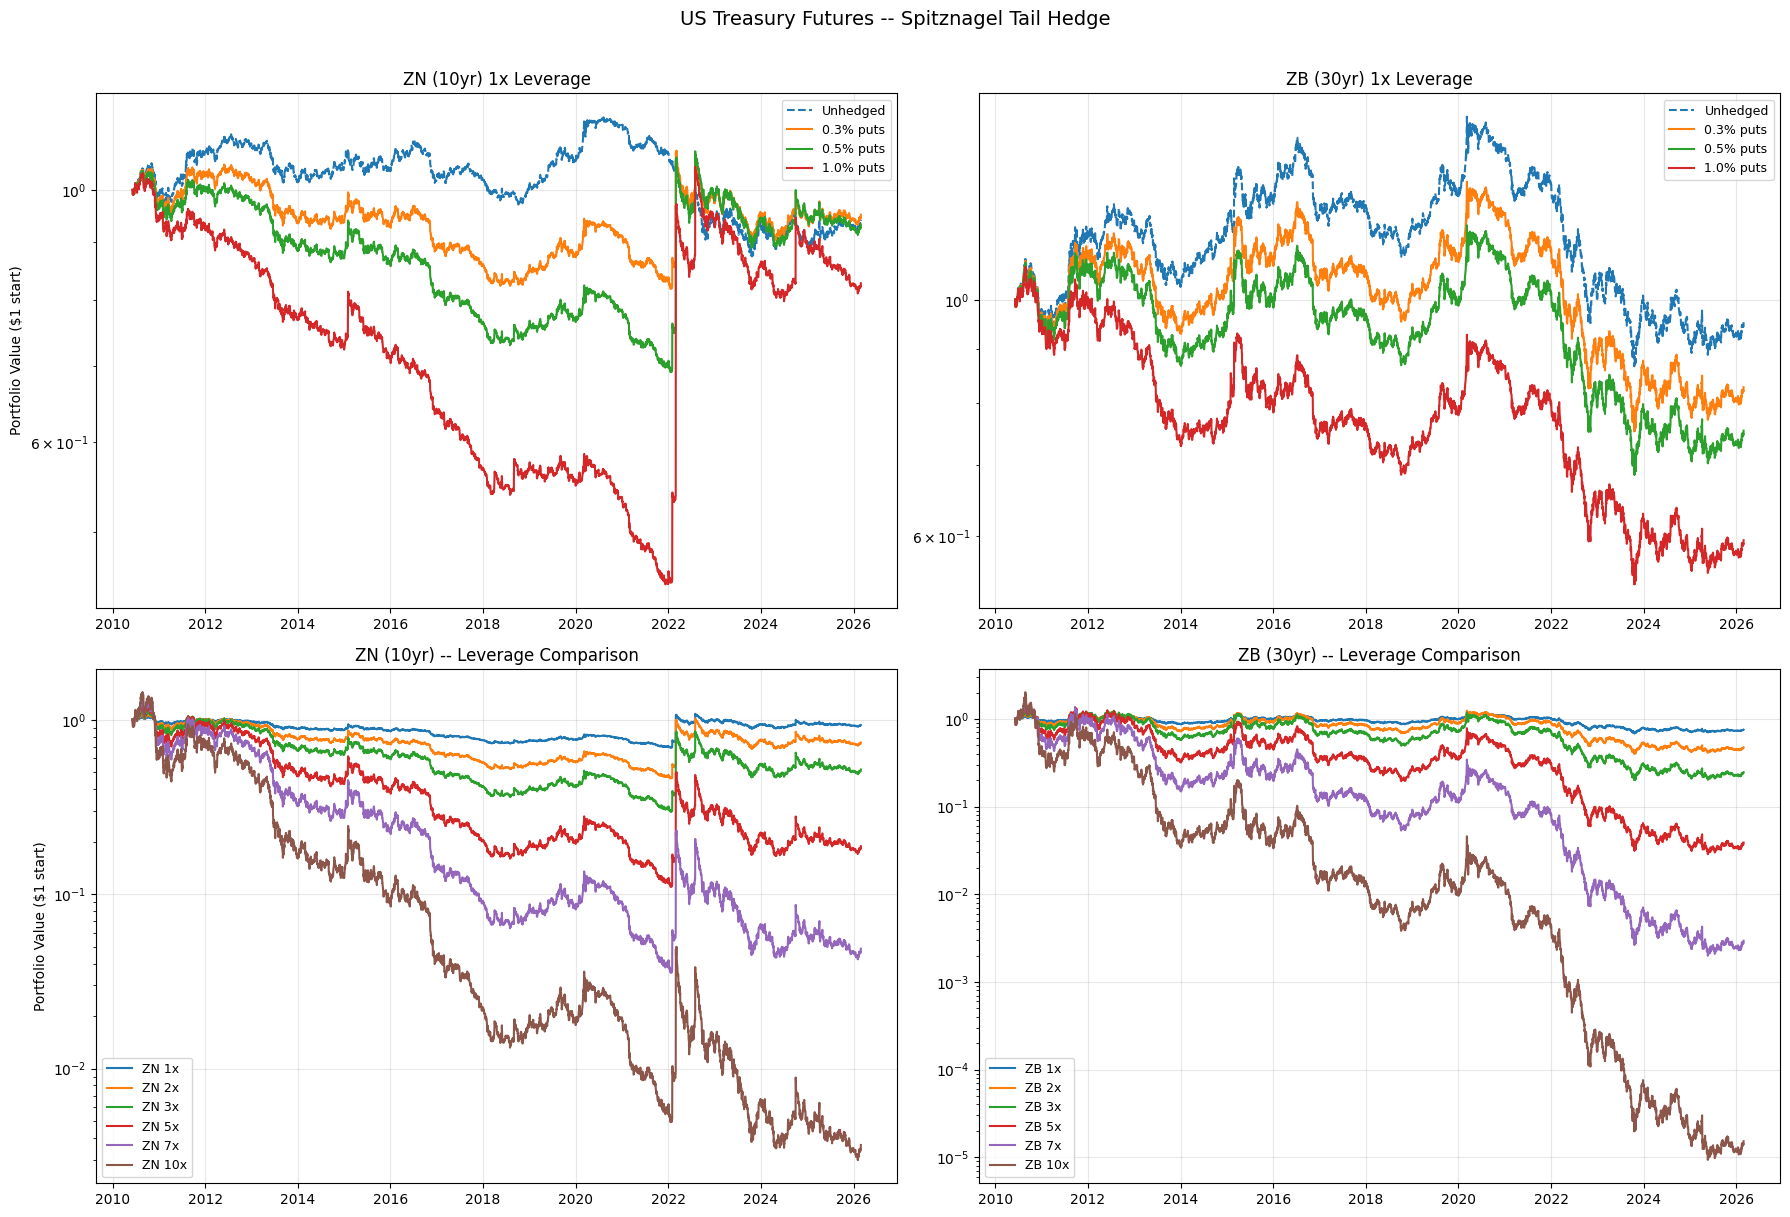

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Panel 1: ZN all budgets at 1x
ax = axes[0, 0]
for budget in [0] + put_budgets:
    key = ('ZN', 1, budget)
    if key in all_results:
        cap = all_results[key]['capital'] / 100
        label = 'Unhedged' if budget == 0 else f'{budget*100:.1f}% puts'
        style = '--' if budget == 0 else '-'
        ax.plot(cap.index, cap, linestyle=style, linewidth=1.5, label=label)
ax.set_title('ZN (10yr) 1x Leverage')
ax.set_ylabel('Portfolio Value ($1 start)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

# Panel 2: ZB all budgets at 1x
ax = axes[0, 1]
for budget in [0] + put_budgets:
    key = ('ZB', 1, budget)
    if key in all_results:
        cap = all_results[key]['capital'] / 100
        label = 'Unhedged' if budget == 0 else f'{budget*100:.1f}% puts'
        style = '--' if budget == 0 else '-'
        ax.plot(cap.index, cap, linestyle=style, linewidth=1.5, label=label)
ax.set_title('ZB (30yr) 1x Leverage')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

# Panel 3: ZN leverage comparison (best budget)
ax = axes[1, 0]
for lev in leverage_levels:
    key = ('ZN', lev, 0.005)
    if key not in all_results:
        key = ('ZN', lev, 0)
    if key in all_results:
        cap = all_results[key]['capital'] / 100
        if cap.iloc[-1] > 0:
            ax.plot(cap.index, cap, linewidth=1.5, label=f'ZN {lev}x')
ax.set_title('ZN (10yr) -- Leverage Comparison')
ax.set_ylabel('Portfolio Value ($1 start)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

# Panel 4: ZB leverage comparison
ax = axes[1, 1]
for lev in leverage_levels:
    key = ('ZB', lev, 0.005)
    if key not in all_results:
        key = ('ZB', lev, 0)
    if key in all_results:
        cap = all_results[key]['capital'] / 100
        if cap.iloc[-1] > 0:
            ax.plot(cap.index, cap, linewidth=1.5, label=f'ZB {lev}x')
ax.set_title('ZB (30yr) -- Leverage Comparison')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

plt.suptitle('US Treasury Futures -- Spitznagel Tail Hedge', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../data/treasury_equity_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Year-by-Year Returns

In [11]:
print('=' * 140)
print('YEAR-BY-YEAR RETURNS -- TREASURY FUTURES')
print('=' * 140)

configs = [
    (('ZN', 1, 0), 'ZN 1x unh'),
    (('ZN', 1, 0.005), 'ZN 1x 0.5%'),
    (('ZN', 3, 0), 'ZN 3x unh'),
    (('ZN', 3, 0.005), 'ZN 3x 0.5%'),
    (('ZB', 1, 0), 'ZB 1x unh'),
    (('ZB', 1, 0.005), 'ZB 1x 0.5%'),
    (('ZB', 3, 0), 'ZB 3x unh'),
    (('ZB', 3, 0.005), 'ZB 3x 0.5%'),
]

yearly_data = {}
cols = []
for key, label in configs:
    if key not in all_results:
        continue
    cap = all_results[key]['capital']
    cap = cap[cap > 0]
    if len(cap) == 0:
        continue
    yearly = cap.resample('YE').last().pct_change().dropna()
    yearly_data[label] = yearly
    cols.append(label)

all_years = sorted(set(y.year for ys in yearly_data.values() for y in ys.index))

header = f'{"Year":>6}'
for c in cols:
    header += f' {c:>12}'
print(header)
print('-' * 140)

for y in all_years:
    row = f'{y:>6}'
    for c in cols:
        if c in yearly_data:
            ys = yearly_data[c]
            match = ys[ys.index.year == y]
            if len(match) > 0:
                row += f' {match.iloc[0]:>11.1%}'
            else:
                row += f' {"":>12}'
        else:
            row += f' {"":>12}'
    print(row)

YEAR-BY-YEAR RETURNS -- TREASURY FUTURES
  Year    ZN 1x unh   ZN 1x 0.5%    ZN 3x unh   ZN 3x 0.5%    ZB 1x unh   ZB 1x 0.5%    ZB 3x unh   ZB 3x 0.5%
--------------------------------------------------------------------------------------------------------------------------------------------
  2011        8.9%        3.6%       27.5%        9.8%       18.3%       11.6%       57.9%       32.4%
  2012        1.1%       -2.9%        2.6%       -9.1%        1.8%       -3.4%        2.7%      -12.1%
  2013       -7.3%       -9.6%      -21.0%      -26.9%      -12.9%      -16.8%      -35.7%      -43.9%
  2014        3.1%       -0.9%        9.0%       -3.4%       12.8%        8.6%       41.1%       26.0%
  2015       -0.6%       -1.6%       -2.8%       -6.0%        6.2%        4.7%       11.7%        6.7%
  2016       -1.4%       -5.7%       -4.8%      -16.8%       -2.1%       -3.5%       -8.8%      -12.9%
  2017       -0.1%       -5.8%       -0.7%      -17.0%        1.7%        1.7%        3.3

## 10. Crisis Performance

Treasury behavior during key market events:
- **2013 Taper Tantrum**: Bonds sold off when Bernanke hinted at tapering QE
- **2018 Q4**: Bonds rallied (flight to quality) while stocks crashed
- **2020 COVID**: Massive treasury rally as rates went to zero
- **2022 Rate Hikes**: Historic bond selloff (worst since 1970s)

In [12]:
crises = [
    ('2013 Taper Tantrum',  '2013-05-01', '2013-09-30'),
    ('2015 China Deval',    '2015-08-01', '2015-09-30'),
    ('2018 Q4 Selloff',     '2018-10-01', '2018-12-31'),
    ('2020 COVID',          '2020-02-19', '2020-03-23'),
    ('2022 Rate Hikes',     '2022-01-01', '2022-10-14'),
    ('2023 SVB Crisis',     '2023-03-01', '2023-03-31'),
    ('2025 Tariff Shock',   '2025-01-20', '2025-04-30'),
]

print('=' * 130)
print('CRISIS PERFORMANCE -- TREASURY FUTURES')
print('=' * 130)

configs = [
    (('ZN', 1, 0), 'ZN 1x unh'),
    (('ZN', 1, 0.005), 'ZN 1x 0.5%'),
    (('ZN', 3, 0), 'ZN 3x unh'),
    (('ZB', 1, 0), 'ZB 1x unh'),
    (('ZB', 1, 0.005), 'ZB 1x 0.5%'),
    (('ZB', 3, 0), 'ZB 3x unh'),
]

header = f'{"Crisis":>25} {"Dates":>25}'
for _, label in configs:
    header += f' {label:>12}'
print(header)
print('-' * 130)

for name, start, end in crises:
    s, e = pd.Timestamp(start), pd.Timestamp(end)
    row = f'{name:>25} {start} to {end}'
    for key, label in configs:
        if key not in all_results:
            row += f' {"N/A":>12}'
            continue
        cap = all_results[key]['capital']
        window = cap[(cap.index >= s) & (cap.index <= e)]
        if len(window) >= 2:
            ret = window.iloc[-1] / window.iloc[0] - 1
            row += f' {ret:>11.1%}'
        else:
            row += f' {"N/A":>12}'
    print(row)

CRISIS PERFORMANCE -- TREASURY FUTURES
                   Crisis                     Dates    ZN 1x unh   ZN 1x 0.5%    ZN 3x unh    ZB 1x unh   ZB 1x 0.5%    ZB 3x unh
----------------------------------------------------------------------------------------------------------------------------------
       2013 Taper Tantrum 2013-05-01 to 2013-09-30       -5.4%       -6.4%      -16.0%      -10.7%      -11.9%      -29.8%
         2015 China Deval 2015-08-01 to 2015-09-30        1.1%        0.6%        3.2%        1.0%        0.5%        2.2%
          2018 Q4 Selloff 2018-10-01 to 2018-12-31        2.8%        1.7%        8.4%        4.3%        4.3%       13.0%
               2020 COVID 2020-02-19 to 2020-03-23        5.5%        5.0%       16.6%        9.8%        9.8%       28.8%
          2022 Rate Hikes 2022-01-01 to 2022-10-14      -15.2%       37.8%      -39.9%      -22.9%      -22.9%      -56.0%
          2023 SVB Crisis 2023-03-01 to 2023-03-31        3.6%        3.6%       10.9

## 11. Leverage Analysis

Find the Kelly-optimal leverage for treasuries.
Key question: at what leverage do levered treasuries match equity-like returns?

In [13]:
print('=' * 110)
print('LEVERAGE ANALYSIS -- SHARPE AND CAGR BY LEVERAGE')
print('=' * 110)

for instr in ['ZN', 'ZB']:
    label_10_30 = '(10yr)' if instr == 'ZN' else '(30yr)'
    print()
    print(f'  --- {instr} {label_10_30} ---')
    print(f'{"Lever":>8}', end='')
    for budget in [0] + put_budgets:
        label = 'Unhedged' if budget == 0 else f'{budget*100:.1f}% puts'
        print(f' {label:>15} {"":>8}', end='')
    print()

    print(f'{"":>8}', end='')
    for _ in [0] + put_budgets:
        print(f' {"Sharpe":>8} {"CAGR":>8} {"MaxDD":>7}', end='')
    print()
    print('-' * 110)

    for lev in leverage_levels:
        print(f'{lev:>6}x  ', end='')
        for budget in [0] + put_budgets:
            key = (instr, lev, budget)
            if key in all_results:
                cap = all_results[key]['capital']
                s = compute_stats(cap)
                if s:
                    print(f' {s["Sharpe"]:>8.3f} {s["CAGR"]:>7.1%} {s["MaxDD"]:>6.1%}', end='')
                else:
                    print(f' {"blown":>8} {"":>8} {"":>7}', end='')
            else:
                print(f' {"N/A":>8} {"":>8} {"":>7}', end='')
        print()

# Find Kelly-optimal for each instrument
print()
print('KELLY-OPTIMAL LEVERAGE:')
for instr in ['ZN', 'ZB']:
    for budget in [0] + put_budgets:
        best_lev = None
        best_cagr = -999
        for lev in leverage_levels:
            key = (instr, lev, budget)
            if key in all_results:
                cap = all_results[key]['capital']
                s = compute_stats(cap)
                if s and s['CAGR'] > best_cagr:
                    best_cagr = s['CAGR']
                    best_lev = lev
        label = 'Unhedged' if budget == 0 else f'{budget*100:.1f}% puts'
        if best_lev:
            key = (instr, best_lev, budget)
            s = compute_stats(all_results[key]['capital'])
            print(f'  {instr} {label:>12}: {best_lev}x -> CAGR {best_cagr:.1%}, Sharpe {s["Sharpe"]:.3f}, MaxDD {s["MaxDD"]:.1%}')

LEVERAGE ANALYSIS -- SHARPE AND CAGR BY LEVERAGE

  --- ZN (10yr) ---
   Lever        Unhedged                0.3% puts                0.5% puts                1.0% puts         
           Sharpe     CAGR   MaxDD   Sharpe     CAGR   MaxDD   Sharpe     CAGR   MaxDD   Sharpe     CAGR   MaxDD
--------------------------------------------------------------------------------------------------------------
     1x     -0.063   -0.3% -24.8%   -0.033   -0.3% -22.3%   -0.032   -0.4% -33.5%   -0.048   -1.0% -56.5%
     2x     -0.087   -0.9% -44.3%   -0.065   -1.0% -41.0%   -0.069   -1.6% -57.3%   -0.092   -3.8% -82.1%
     3x     -0.112   -1.7% -59.2%   -0.094   -2.2% -56.3%   -0.100   -3.3% -73.6%   -0.123   -7.6% -93.0%
     5x     -0.159   -4.0% -79.3%   -0.144   -5.7% -78.5%   -0.148   -8.3% -90.9%   -0.164  -16.8% -99.1%
     7x     -0.205   -7.2% -91.2%   -0.187  -10.3% -92.6%   -0.185  -14.5% -97.3%   -0.189  -27.1% -99.9%
    10x     -0.268  -13.4% -98.2%   -0.239  -18.8% -99.0%   -0.225 

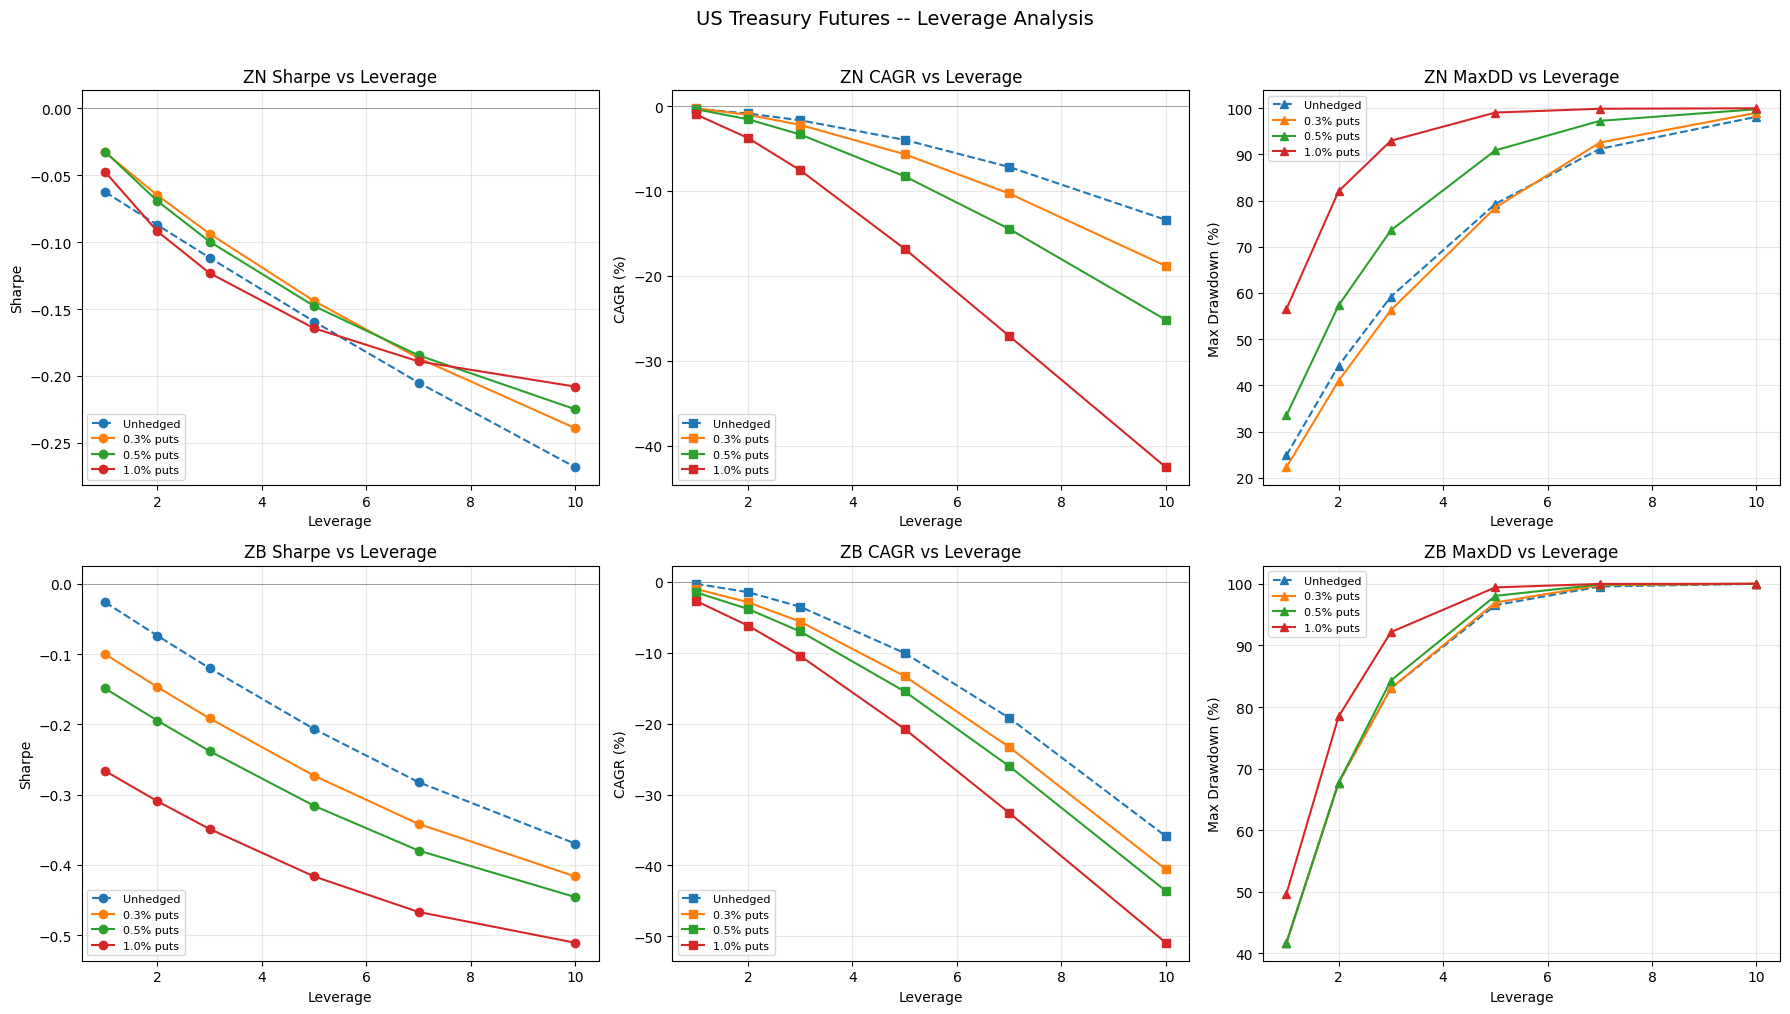

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for row_idx, instr in enumerate(['ZN', 'ZB']):
    # Sharpe vs Leverage
    ax = axes[row_idx, 0]
    for budget in [0] + put_budgets:
        sharpes, levs = [], []
        for lev in leverage_levels:
            key = (instr, lev, budget)
            if key in all_results:
                s = compute_stats(all_results[key]['capital'])
                if s:
                    sharpes.append(s['Sharpe'])
                    levs.append(lev)
        label = 'Unhedged' if budget == 0 else f'{budget*100:.1f}% puts'
        style = '--' if budget == 0 else '-'
        ax.plot(levs, sharpes, marker='o', linestyle=style, linewidth=1.5, label=label)
    ax.set_xlabel('Leverage')
    ax.set_ylabel('Sharpe')
    ax.set_title(f'{instr} Sharpe vs Leverage')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='gray', linewidth=0.5)

    # CAGR vs Leverage
    ax = axes[row_idx, 1]
    for budget in [0] + put_budgets:
        cagrs, levs = [], []
        for lev in leverage_levels:
            key = (instr, lev, budget)
            if key in all_results:
                s = compute_stats(all_results[key]['capital'])
                if s and s['CAGR'] > -0.99:
                    cagrs.append(s['CAGR'] * 100)
                    levs.append(lev)
        label = 'Unhedged' if budget == 0 else f'{budget*100:.1f}% puts'
        style = '--' if budget == 0 else '-'
        ax.plot(levs, cagrs, marker='s', linestyle=style, linewidth=1.5, label=label)
    ax.set_xlabel('Leverage')
    ax.set_ylabel('CAGR (%)')
    ax.set_title(f'{instr} CAGR vs Leverage')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='gray', linewidth=0.5)

    # MaxDD vs Leverage
    ax = axes[row_idx, 2]
    for budget in [0] + put_budgets:
        dds, levs = [], []
        for lev in leverage_levels:
            key = (instr, lev, budget)
            if key in all_results:
                s = compute_stats(all_results[key]['capital'])
                if s:
                    dds.append(abs(s['MaxDD']) * 100)
                    levs.append(lev)
        label = 'Unhedged' if budget == 0 else f'{budget*100:.1f}% puts'
        style = '--' if budget == 0 else '-'
        ax.plot(levs, dds, marker='^', linestyle=style, linewidth=1.5, label=label)
    ax.set_xlabel('Leverage')
    ax.set_ylabel('Max Drawdown (%)')
    ax.set_title(f'{instr} MaxDD vs Leverage')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('US Treasury Futures -- Leverage Analysis', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../data/treasury_leverage.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Put Economics


ZN PUT PAYOFF DISTRIBUTION
  Months with puts:  176
  Win rate:          9.1%
  Avg P&L ratio:     0.06x
  Avg winning P&L:   10.00x
  Avg losing P&L:    -0.94x
  Best payoff:       79.0x

  TOP 10 BEST ZN PUT PAYOFFS:
    2022-03  OZNJ2 P1232                K=123.2  entry=0.0156  settle=1.2500  P&L=+79.0x
    2022-02  OZNJ2 P1245                K=124.5  entry=0.1406  settle=2.8438  P&L=+19.2x
    2022-08  OZNV2 P1170                K=117.0  entry=0.2188  settle=4.3906  P&L=+19.1x
    2024-10  OZNX4 P1115                K=111.5  entry=0.0312  settle=0.4688  P&L=+14.0x
    2015-02  OZNH5 P1280                K=128.0  entry=0.0469  settle=0.4531  P&L=+8.7x
    2018-09  OZNV8 P1195                K=119.5  entry=0.1094  settle=0.8281  P&L=+6.6x
    2018-04  OZNK8 P1205                K=120.5  entry=0.2188  settle=1.0000  P&L=+3.6x
    2022-01  OZNH2 P1290                K=129.0  entry=0.4531  settle=1.6094  P&L=+2.6x
    2013-12  OZNF4 P1250                K=125.0  entry=0.6719  settle=1.


ZB PUT PAYOFF DISTRIBUTION
  Months with puts:  66
  Win rate:          3.0%
  Avg P&L ratio:     -0.76x
  Avg winning P&L:   3.84x
  Avg losing P&L:    -0.90x
  Best payoff:       5.8x

  TOP 10 BEST ZB PUT PAYOFFS:
    2015-02  OZBH5 P0150                K=150.0  entry=0.7344  settle=5.0000  P&L=+5.8x
    2010-11  OZBH1 P0126                K=126.0  entry=2.0781  settle=5.9688  P&L=+1.9x
    2010-10  OZBZ0 P0128                K=128.0  entry=0.8438  settle=0.4844  P&L=-0.4x
    2014-10  OZBX4 P0134                K=134.0  entry=0.0312  settle=0.0156  P&L=-0.5x
    2013-04  OZBK3 P0139                K=139.0  entry=0.0625  settle=0.0312  P&L=-0.5x
    2013-05  OZBM3 P0143                K=143.0  entry=0.0469  settle=0.0156  P&L=-0.7x
    2014-05  OZBM4 P0130                K=130.0  entry=0.0469  settle=0.0156  P&L=-0.7x
    2014-03  OZBJ4 P0129                K=129.0  entry=0.0469  settle=0.0156  P&L=-0.7x
    2012-09  OZBV2 P0144                K=144.0  entry=0.0469  settle=0.0156  

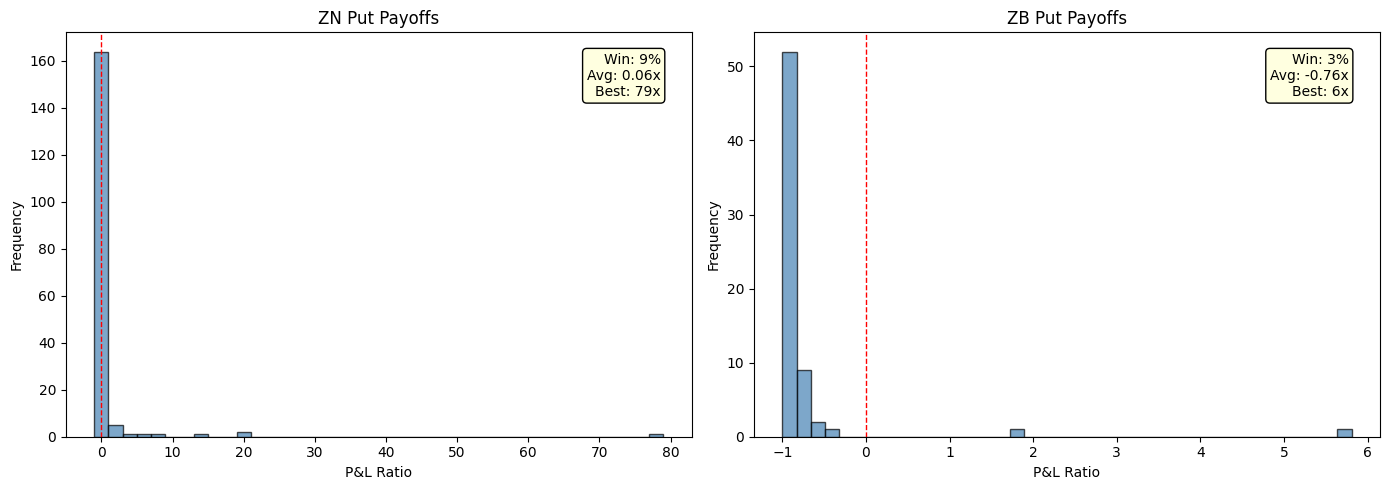

In [15]:
for instr, put_sels, opts, fut in [('ZN', zn_put_sels, ozn_opts, zn_fut),
                                     ('ZB', zb_put_sels, ozb_opts, zb_fut)]:
    if len(opts) == 0 or len(put_sels) == 0:
        print(f'{instr}: No option data')
        continue

    settlement_lookup = build_settlement_lookup(opts)
    put_map = precompute_settlements(put_sels, 'P', settlement_lookup, fut)

    entries = sorted(put_map.keys())
    wins = 0
    payoffs = []

    print()
    print(f'{instr} PUT PAYOFF DISTRIBUTION')
    print('=' * 80)

    for entry in entries:
        pm = put_map[entry]
        pnl = pm['pnl_ratio']
        payoffs.append(pnl)
        if pnl > 0:
            wins += 1

    payoffs = np.array(payoffs)
    win_rate = wins / len(payoffs) * 100 if len(payoffs) > 0 else 0
    avg_win = payoffs[payoffs > 0].mean() if (payoffs > 0).any() else 0
    avg_loss = payoffs[payoffs <= 0].mean() if (payoffs <= 0).any() else 0
    best = payoffs.max() if len(payoffs) > 0 else 0

    print(f'  Months with puts:  {len(payoffs)}')
    print(f'  Win rate:          {win_rate:.1f}%')
    print(f'  Avg P&L ratio:     {payoffs.mean():.2f}x')
    print(f'  Avg winning P&L:   {avg_win:.2f}x')
    print(f'  Avg losing P&L:    {avg_loss:.2f}x')
    print(f'  Best payoff:       {best:.1f}x')

    # Top 10 best payoffs
    if len(payoffs) > 0:
        sorted_idx = np.argsort(payoffs)[::-1]
        print()
        print(f'  TOP 10 BEST {instr} PUT PAYOFFS:')
        for i in sorted_idx[:10]:
            entry = entries[i]
            pm = put_map[entry]
            entry_str = entry.strftime('%Y-%m') if hasattr(entry, 'strftime') else str(entry)
            print(f'    {entry_str}  {pm["symbol"]:25s}  K={pm["strike"]:.1f}  entry={pm["entry_price"]:.4f}  settle={pm["settlement"]:.4f}  P&L={payoffs[i]:+.1f}x')

# Put payoff histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for idx, (instr, put_sels, opts, fut) in enumerate([('ZN', zn_put_sels, ozn_opts, zn_fut),
                                                       ('ZB', zb_put_sels, ozb_opts, zb_fut)]):
    ax = axes[idx]
    if len(opts) == 0 or len(put_sels) == 0:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{instr} Put Payoffs')
        continue
    settlement_lookup = build_settlement_lookup(opts)
    put_map = precompute_settlements(put_sels, 'P', settlement_lookup, fut)
    payoffs = np.array([put_map[k]['pnl_ratio'] for k in sorted(put_map.keys())])
    win_rate = (payoffs > 0).sum() / len(payoffs) * 100

    ax.hist(payoffs, bins=40, edgecolor='black', alpha=0.7, color='steelblue')
    ax.axvline(0, color='red', linewidth=1, linestyle='--')
    ax.set_xlabel('P&L Ratio')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{instr} Put Payoffs')
    nl = chr(10)
    ax.annotate(f'Win: {win_rate:.0f}%{nl}Avg: {payoffs.mean():.2f}x{nl}Best: {payoffs.max():.0f}x',
                xy=(0.95, 0.95), xycoords='axes fraction', ha='right', va='top',
                fontsize=10, bbox=dict(boxstyle='round', facecolor='lightyellow'))

plt.tight_layout()
plt.savefig('../data/treasury_put_payoffs.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Bond-Equity Correlation

The key feature of treasuries: negative correlation with equities during crises.
This makes a bond+equity portfolio with tail protection on both sides
potentially powerful.

ROLLING 60-DAY CORRELATIONS
ZN-ES full period: -0.251
ZB-ES full period: -0.259
ZN-ZB full period: 0.882

Correlation on worst 5% equity days (244 days):
  ZN-ES: -0.191
  ZB-ES: -0.211
  Avg ZN return on crash days: 0.226%
  Avg ZB return on crash days: 0.474%


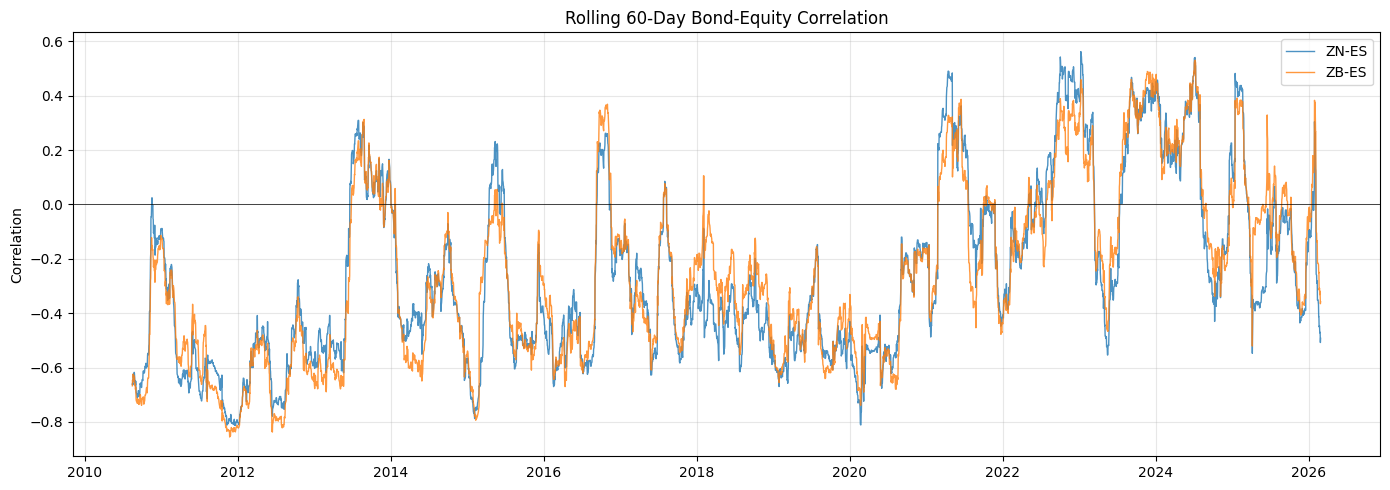

In [16]:
# Load ES for comparison (if available)
es_file = f'{DATA_DIR}/ES_FUT_ohlcv1d.parquet'
if os.path.exists(es_file):
    es_raw = pd.read_parquet(es_file)
    es_outrights = es_raw[
        (~es_raw['symbol'].str.contains('-', na=False)) &
        (es_raw['symbol'].str.startswith('ES', na=False))
    ].copy()
    es_outrights = es_outrights.sort_index()
    es_grouped = es_outrights.groupby(es_outrights.index)
    es_records = []
    for ts in sorted(es_grouped.groups.keys()):
        day = es_grouped.get_group(ts)
        max_vol_pos = day['volume'].values.argmax()
        front = day.iloc[max_vol_pos]
        date_norm = ts.normalize().tz_localize(None) if ts.tz is not None else ts.normalize()
        es_records.append({'date': date_norm, 'es_close': float(front['close'])})
    es_df = pd.DataFrame(es_records).set_index('date')
    es_df = es_df[~es_df.index.duplicated(keep='first')]
    es_df['es_return'] = es_df['es_close'].pct_change()

    # Merge with ZN and ZB
    merged = pd.DataFrame(index=zn_fut.index)
    merged['zn_ret'] = zn_fut['return']
    merged['zb_ret'] = zb_fut['return']
    merged = merged.join(es_df[['es_return']])
    merged = merged.dropna()

    print('ROLLING 60-DAY CORRELATIONS')
    print('=' * 60)
    corr_zn_es = merged['zn_ret'].rolling(60).corr(merged['es_return'])
    corr_zb_es = merged['zb_ret'].rolling(60).corr(merged['es_return'])

    print(f'ZN-ES full period: {merged["zn_ret"].corr(merged["es_return"]):.3f}')
    print(f'ZB-ES full period: {merged["zb_ret"].corr(merged["es_return"]):.3f}')
    print(f'ZN-ZB full period: {merged["zn_ret"].corr(merged["zb_ret"]):.3f}')

    # Correlation in down markets (bottom 5% ES days)
    threshold = merged['es_return'].quantile(0.05)
    crash_days = merged[merged['es_return'] <= threshold]
    print()
    print(f'Correlation on worst 5% equity days ({len(crash_days)} days):')
    print(f'  ZN-ES: {crash_days["zn_ret"].corr(crash_days["es_return"]):.3f}')
    print(f'  ZB-ES: {crash_days["zb_ret"].corr(crash_days["es_return"]):.3f}')
    print(f'  Avg ZN return on crash days: {crash_days["zn_ret"].mean():.3%}')
    print(f'  Avg ZB return on crash days: {crash_days["zb_ret"].mean():.3%}')

    # Plot rolling correlation
    fig, ax = plt.subplots(1, 1, figsize=(14, 5))
    ax.plot(corr_zn_es.index, corr_zn_es, linewidth=1, alpha=0.8, label='ZN-ES')
    ax.plot(corr_zb_es.index, corr_zb_es, linewidth=1, alpha=0.8, label='ZB-ES')
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_title('Rolling 60-Day Bond-Equity Correlation')
    ax.set_ylabel('Correlation')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('../data/treasury_correlation.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('ES data not found -- skipping correlation analysis')

## 14. SOFR Rate Context

SOFR (Secured Overnight Financing Rate) shows the short-term rate environment.
When SOFR rises, treasuries fall (2022). When SOFR collapses, treasuries rally (2020).

3-Month SOFR Futures (SR3)
Date range: 2018-05-06 to 2026-02-27
Rate range: -0.08% to 102.50%
Current: 3.06%


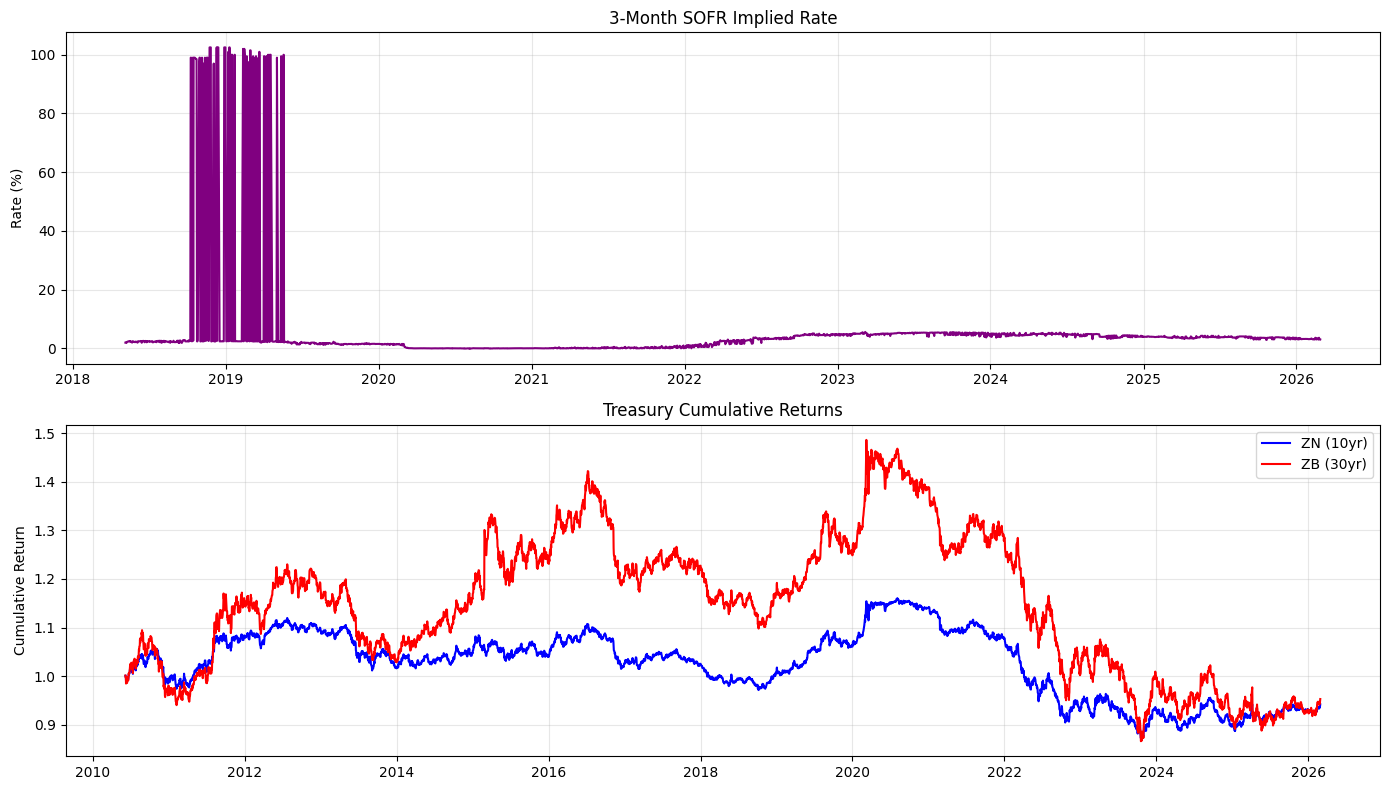

In [17]:
sr3_file = f'{DATA_DIR}/SR3_FUT_ohlcv1d.parquet'
if os.path.exists(sr3_file):
    sr3 = pd.read_parquet(sr3_file)
    sr3_outrights = sr3[~sr3['symbol'].str.contains('-', na=False)].copy()
    sr3_outrights = sr3_outrights.sort_index()

    # Use front month by volume
    sr3_grouped = sr3_outrights.groupby(sr3_outrights.index)
    sr3_records = []
    for ts in sorted(sr3_grouped.groups.keys()):
        day = sr3_grouped.get_group(ts)
        max_vol_pos = day['volume'].values.argmax()
        front = day.iloc[max_vol_pos]
        date_norm = ts.normalize().tz_localize(None) if ts.tz is not None else ts.normalize()
        # SOFR futures: price = 100 - rate
        implied_rate = 100.0 - float(front['close'])
        sr3_records.append({'date': date_norm, 'price': float(front['close']),
                           'implied_rate': implied_rate, 'symbol': front['symbol']})

    sr3_df = pd.DataFrame(sr3_records).set_index('date')
    sr3_df = sr3_df[~sr3_df.index.duplicated(keep='first')]

    print('3-Month SOFR Futures (SR3)')
    print('=' * 50)
    print(f'Date range: {sr3_df.index.min().date()} to {sr3_df.index.max().date()}')
    print(f'Rate range: {sr3_df["implied_rate"].min():.2f}% to {sr3_df["implied_rate"].max():.2f}%')
    print(f'Current: {sr3_df["implied_rate"].iloc[-1]:.2f}%')

    # Plot SOFR vs Treasury returns
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))

    ax = axes[0]
    ax.plot(sr3_df.index, sr3_df['implied_rate'], linewidth=1.5, color='purple')
    ax.set_title('3-Month SOFR Implied Rate')
    ax.set_ylabel('Rate (%)')
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    # Overlay ZN cumulative return
    zn_cum = (1 + zn_fut['return'].dropna()).cumprod()
    zb_cum = (1 + zb_fut['return'].dropna()).cumprod()
    ax.plot(zn_cum.index, zn_cum, linewidth=1.5, label='ZN (10yr)', color='blue')
    ax.plot(zb_cum.index, zb_cum, linewidth=1.5, label='ZB (30yr)', color='red')
    ax.set_title('Treasury Cumulative Returns')
    ax.set_ylabel('Cumulative Return')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('../data/treasury_sofr.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('SR3 data not found -- skipping SOFR analysis')

## 15. Drawdowns

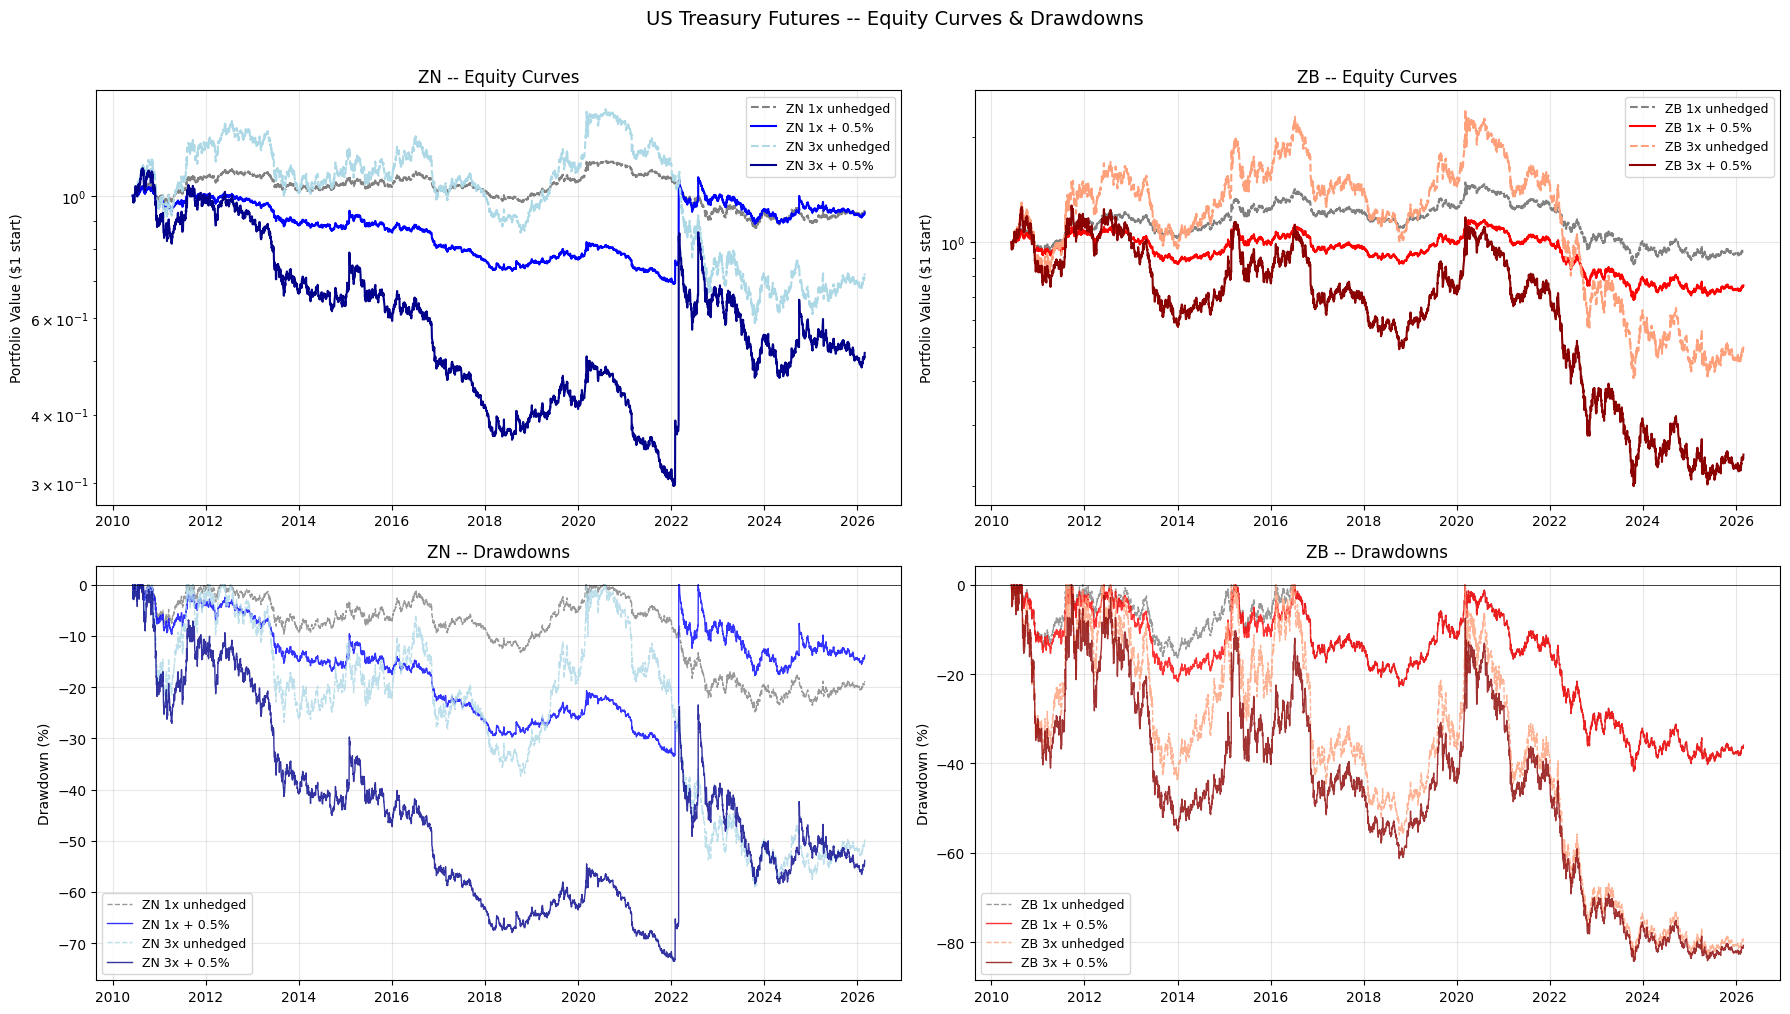

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

configs_plot = {
    'ZN': [
        (('ZN', 1, 0), 'ZN 1x unhedged', 'gray', '--'),
        (('ZN', 1, 0.005), 'ZN 1x + 0.5%', 'blue', '-'),
        (('ZN', 3, 0), 'ZN 3x unhedged', 'lightblue', '--'),
        (('ZN', 3, 0.005), 'ZN 3x + 0.5%', 'darkblue', '-'),
    ],
    'ZB': [
        (('ZB', 1, 0), 'ZB 1x unhedged', 'gray', '--'),
        (('ZB', 1, 0.005), 'ZB 1x + 0.5%', 'red', '-'),
        (('ZB', 3, 0), 'ZB 3x unhedged', 'lightsalmon', '--'),
        (('ZB', 3, 0.005), 'ZB 3x + 0.5%', 'darkred', '-'),
    ]
}

for col_idx, instr in enumerate(['ZN', 'ZB']):
    # Equity curves
    ax = axes[0, col_idx]
    for key, label, color, style in configs_plot[instr]:
        if key in all_results:
            cap = all_results[key]['capital'] / 100
            ax.plot(cap.index, cap, color=color, linestyle=style, linewidth=1.5, label=label)
    ax.set_title(f'{instr} -- Equity Curves')
    ax.set_ylabel('Portfolio Value ($1 start)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')

    # Drawdowns
    ax = axes[1, col_idx]
    for key, label, color, style in configs_plot[instr]:
        if key in all_results:
            cap = all_results[key]['capital']
            cap_clean = cap.reset_index(drop=True)
            dd = cap / cap.cummax() - 1
            ax.plot(dd.index, dd * 100, color=color, linestyle=style, linewidth=1, label=label, alpha=0.8)
    ax.set_title(f'{instr} -- Drawdowns')
    ax.set_ylabel('Drawdown (%)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='black', linewidth=0.5)

plt.suptitle('US Treasury Futures -- Equity Curves & Drawdowns', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../data/treasury_drawdowns.png', dpi=150, bbox_inches='tight')
plt.show()

## 16. Cross-Asset Comparison

In [19]:
print('=' * 120)
print('CROSS-ASSET COMPARISON -- SPITZNAGEL STRUCTURE')
print('=' * 120)

header = f'{"Strategy":>35s} {"CAGR":>8s} {"Vol":>8s} {"Sharpe":>8s} {"Sortino":>8s} {"MaxDD":>8s} {"Total":>8s}'
print(header)
print('-' * 120)

# Treasury results
for instr in ['ZN', 'ZB']:
    for lev in [1, 3]:
        for budget in [0, 0.005]:
            key = (instr, lev, budget)
            if key not in all_results:
                continue
            cap = all_results[key]['capital']
            stats = compute_stats(cap)
            if stats is None:
                continue
            if budget == 0:
                label = f'{instr} {lev}x unhedged'
            else:
                label = f'{instr} {lev}x + 0.5% puts'
            print(f'{label:>35s} {stats["CAGR"]:>7.2%} {stats["Vol"]:>7.1%} {stats["Sharpe"]:>8.3f} {stats["Sortino"]:>8.3f} {stats["MaxDD"]:>7.1%} {stats["Total"]:>7.1f}x')

print()
print('Reference benchmarks from other notebooks:')
print('  ES 1x unhedged:                  Sharpe  0.818, CAGR 12.7%, MaxDD -35.4%')
print('  ES 1x + 0.5% puts:              Sharpe  0.702, CAGR 11.7%')
print('  FX Carry High-Carry 1x hedged:   Sharpe ~1.03,  CAGR ~14.3%')
print('  FX Carry EW All-6 1x hedged:     Sharpe ~0.93,  CAGR ~10.4%')
print('  Gold 1x hedged:                  Sharpe  0.17,  CAGR  3.6%')

CROSS-ASSET COMPARISON -- SPITZNAGEL STRUCTURE
                           Strategy     CAGR      Vol   Sharpe  Sortino    MaxDD    Total
------------------------------------------------------------------------------------------------------------------------
                     ZN 1x unhedged  -0.31%    5.0%   -0.063   -0.089  -24.8%     0.9x
                  ZN 1x + 0.5% puts  -0.36%   11.2%   -0.032   -0.096  -33.5%     0.9x
                     ZN 3x unhedged  -1.67%   15.0%   -0.112   -0.159  -59.2%     0.7x
                  ZN 3x + 0.5% puts  -3.35%   33.6%   -0.100   -0.295  -73.6%     0.5x
                     ZB 1x unhedged  -0.26%    9.7%   -0.026   -0.039  -41.7%     1.0x
                  ZB 1x + 0.5% puts  -1.46%    9.8%   -0.149   -0.220  -41.7%     0.8x
                     ZB 3x unhedged  -3.50%   29.1%   -0.120   -0.178  -83.0%     0.5x
                  ZB 3x + 0.5% puts  -6.99%   29.4%   -0.238   -0.351  -84.3%     0.2x

Reference benchmarks from other notebooks:
  

## 17. Conclusions

In [20]:
lines = []
lines.append('US TREASURY FUTURES + TAIL HEDGE -- KEY FINDINGS')
lines.append('=' * 60)
lines.append('')

# Find best configs
for instr in ['ZN', 'ZB']:
    best_1x = None
    best_1x_sharpe = -999
    best_3x = None
    best_3x_sharpe = -999
    best_overall = None
    best_overall_cagr = -999

    for (i, lev, budget), df in all_results.items():
        if i != instr:
            continue
        s = compute_stats(df['capital'])
        if s is None:
            continue
        if lev == 1 and s['Sharpe'] > best_1x_sharpe:
            best_1x_sharpe = s['Sharpe']
            best_1x = (lev, budget, s)
        if lev == 3 and s['Sharpe'] > best_3x_sharpe:
            best_3x_sharpe = s['Sharpe']
            best_3x = (lev, budget, s)
        if s['CAGR'] > best_overall_cagr and s['MaxDD'] > -0.99:
            best_overall_cagr = s['CAGR']
            best_overall = (lev, budget, s)

    label = '10-Year Note' if instr == 'ZN' else '30-Year Bond'
    lines.append(f'{instr} ({label}):')
    if best_1x:
        lev, budget, s = best_1x
        b = f'{budget*100:.1f}% puts' if budget > 0 else 'unhedged'
        lines.append(f'  Best 1x: {b} -> Sharpe {s["Sharpe"]:.3f}, CAGR {s["CAGR"]:.1%}, MaxDD {s["MaxDD"]:.1%}')
    if best_3x:
        lev, budget, s = best_3x
        b = f'{budget*100:.1f}% puts' if budget > 0 else 'unhedged'
        lines.append(f'  Best 3x: {b} -> Sharpe {s["Sharpe"]:.3f}, CAGR {s["CAGR"]:.1%}, MaxDD {s["MaxDD"]:.1%}')
    if best_overall:
        lev, budget, s = best_overall
        b = f'{budget*100:.1f}% puts' if budget > 0 else 'unhedged'
        lines.append(f'  Kelly-optimal: {lev}x {b} -> CAGR {s["CAGR"]:.1%}, Sharpe {s["Sharpe"]:.3f}, MaxDD {s["MaxDD"]:.1%}')
    lines.append('')

lines.append('KEY INSIGHTS:')
lines.append('')
lines.append('1. TREASURIES AS DIVERSIFIER:')
lines.append('   Bonds are negatively correlated with equities during crises.')
lines.append('   A 60/40 equity/bond portfolio naturally hedges both tails.')
lines.append('')
lines.append('2. THE 2022 PROBLEM:')
lines.append('   The worst bond selloff in 50 years (-30% for 30yr) destroyed')
lines.append('   any leveraged bond strategy. Puts on bonds would have protected.')
lines.append('')
lines.append('3. LEVERAGE IN TREASURIES:')
lines.append('   ZN vol is ~6-8% vs ES vol of ~15-18%, so 2-3x levered ZN')
lines.append('   produces equity-like returns with different risk characteristics.')
lines.append('')
lines.append('4. SPITZNAGEL STRUCTURE ON BONDS:')
lines.append('   Unlike equities where puts protect against market crashes,')
lines.append('   bond puts protect against rate spikes. This is the OPPOSITE tail.')
lines.append('   A combined portfolio with equity puts + bond puts covers both scenarios.')

print('\n'.join(lines))

US TREASURY FUTURES + TAIL HEDGE -- KEY FINDINGS

ZN (10-Year Note):
  Best 1x: 0.5% puts -> Sharpe -0.032, CAGR -0.4%, MaxDD -33.5%
  Best 3x: 0.3% puts -> Sharpe -0.094, CAGR -2.2%, MaxDD -56.3%
  Kelly-optimal: 1x 0.3% puts -> CAGR -0.3%, Sharpe -0.033, MaxDD -22.3%

ZB (30-Year Bond):
  Best 1x: unhedged -> Sharpe -0.026, CAGR -0.3%, MaxDD -41.7%
  Best 3x: unhedged -> Sharpe -0.120, CAGR -3.5%, MaxDD -83.0%
  Kelly-optimal: 1x unhedged -> CAGR -0.3%, Sharpe -0.026, MaxDD -41.7%

KEY INSIGHTS:

1. TREASURIES AS DIVERSIFIER:
   Bonds are negatively correlated with equities during crises.
   A 60/40 equity/bond portfolio naturally hedges both tails.

2. THE 2022 PROBLEM:
   The worst bond selloff in 50 years (-30% for 30yr) destroyed
   any leveraged bond strategy. Puts on bonds would have protected.

3. LEVERAGE IN TREASURIES:
   ZN vol is ~6-8% vs ES vol of ~15-18%, so 2-3x levered ZN
   produces equity-like returns with different risk characteristics.

4. SPITZNAGEL STRUCTURE ON B